<a href="https://colab.research.google.com/github/Sheriff414/my_deeplearning_model/blob/master/model_observability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [ ]:
(x_train, y_train), (x_test, y_test)=keras.datasets.mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
x_train.shape

(60000, 28, 28)

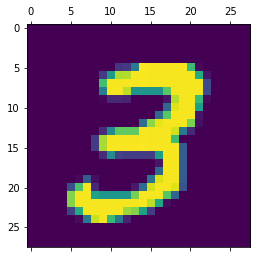

In [ ]:
plt.matshow(x_train[7])

In [ ]:
x_train=x_train/255
x_test=x_test/255

In [ ]:
x_train_flattened=x_train.reshape(len(x_train), 28*28)
x_test_flattened=x_test.reshape(len(x_test), 28*28)

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2748 - accuracy: 0.9208
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1258 - accuracy: 0.9625
Epoch 3/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0883 - accuracy: 0.9737
Epoch 4/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0677 - accuracy: 0.9799
Epoch 5/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0527 - accuracy: 0.9837


In [ ]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 1ms/step - loss: 0.0933 - accuracy: 0.9707


[0.09332592040300369, 0.9707000255584717]

In [ ]:
y_predicted=model.predict(x_test)
y_predicted[0]

In [ ]:
plt.matshow(x_test[0])

In [ ]:
np.argmax(y_predicted[0])

In [ ]:
y_predicted_labels=[np]

In [ ]:
cm=tf.math.confusion_matrix(labels=y_test, predictions=[np.argmax(i) for i in y_predicted])
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 961,    0,    2,    0,    1,    8,    2,    3,    2,    1],
       [   0, 1120,    5,    2,    0,    1,    2,    0,    5,    0],
       [   4,    1, 1001,    8,    2,    1,    2,    6,    7,    0],
       [   0,    0,    3,  979,    0,   16,    0,    6,    2,    4],
       [   0,    0,    2,    0,  960,    3,    5,    2,    2,    8],
       [   2,    0,    0,    4,    2,  877,    1,    0,    5,    1],
       [   1,    2,    1,    1,    6,   12,  933,    0,    2,    0],
       [   0,    3,    7,    0,    1,    2,    0, 1011,    1,    3],
       [   4,    0,    5,   13,    7,   17,    1,    8,  915,    4],
       [   0,    4,    0,    6,   18,   12,    1,   12,    6,  950]],
      dtype=int32)>

Text(69.0, 0.5, 'Truth')

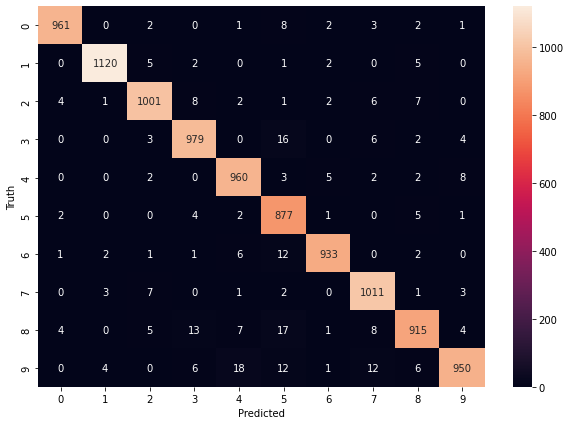

In [ ]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report


In [ ]:
a=classification_report(y_test,[np.argmax(i) for i in y_predicted])

In [ ]:
print(a)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.96      0.98      0.97       982
           5       0.92      0.98      0.95       892
           6       0.99      0.97      0.98       958
           7       0.96      0.98      0.97      1028
           8       0.97      0.94      0.95       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

